# Extract Failed Entries From Hooktheory JSON

这个 Notebook 会：
1. 读取 `output/failures_krn_final.log`
2. 从 `data/Hooktheory.json.gz` 抽取对应条目
3. 生成可视化 DataFrame
4. 导出 `output/analysis/failure_entries.json` 和 `failure_entries.jsonl`


In [5]:
from pathlib import Path
import gzip
import json
import pandas as pd

FAIL_LOG = Path('output/failures_krn_final.log')
DATA_GZ = Path('data/Hooktheory.json.gz')
OUT_JSON = Path('output/analysis/failure_entries.json')
OUT_JSONL = Path('output/analysis/failure_entries.jsonl')

print('FAIL_LOG exists:', FAIL_LOG.exists())
print('DATA_GZ exists:', DATA_GZ.exists())

FAIL_LOG exists: True
DATA_GZ exists: True


In [6]:
# 读取失败ID
failed_ids = []
failure_reasons = {}
for line in FAIL_LOG.read_text(encoding='utf-8').splitlines():
    if not line.strip():
        continue
    parts = line.split('\t', 1)
    sid = parts[0].strip()
    reason = parts[1].strip() if len(parts) > 1 else 'UNKNOWN'
    failed_ids.append(sid)
    failure_reasons[sid] = reason

print('failed ids:', len(failed_ids))
print('sample:', failed_ids[:5])

failed ids: 98
sample: ['yZOxVKOModq', 'pyvgPnPKoYq', 'l_NgbYOMmQA', 'wnvgyyb_gkA', 'AROmNQGjoNw']


In [7]:
# 加载全量数据并抽取失败条目
with gzip.open(DATA_GZ, 'rt', encoding='utf-8') as f:
    all_data = json.load(f)

failed_entries = {sid: all_data[sid] for sid in failed_ids if sid in all_data}
missing_ids = [sid for sid in failed_ids if sid not in all_data]

print('extracted entries:', len(failed_entries))
print('missing in dataset:', len(missing_ids))

extracted entries: 98
missing in dataset: 0


In [8]:
# 生成摘要表，便于可视化筛查
rows = []
for sid, entry in failed_entries.items():
    hook = entry.get('hooktheory') or {}
    ann = entry.get('annotations') or {}
    melody = ann.get('melody') or []
    harmony = ann.get('harmony') or []
    rows.append({
        'id': sid,
        'reason': failure_reasons.get(sid, ''),
        'artist': hook.get('artist', ''),
        'song': hook.get('song', ''),
        'split': entry.get('split', ''),
        'num_beats': ann.get('num_beats', None),
        'melody_count': len(melody),
        'harmony_count': len(harmony),
        'has_melody': len(melody) > 0,
        'has_harmony': len(harmony) > 0,
        'youtube_url': (entry.get('youtube') or {}).get('url', ''),
        'hooktheory_url': (hook.get('urls') or {}).get('song', '')
    })

df = pd.DataFrame(rows).sort_values(['reason', 'artist', 'song']).reset_index(drop=True)
df.head(20)

,id,reason,artist,song,split,num_beats,melody_count,harmony_count,has_melody,has_harmony,youtube_url,hooktheory_url
0,jDgXee-ExKl,EMPTY_SCORE,9voltrobot,test-song,TRAIN,32.0,0,0,False,False,https://www.youtube.com/watch?v=None,https://www.hooktheory.com/theorytab/view/9vol...
1,veoYqlPnodn,EMPTY_SCORE,a-ha,take-on-me,TRAIN,32.0,0,0,False,False,https://www.youtube.com/watch?v=djV11Xbc914,https://www.hooktheory.com/theorytab/view/a-ha...
2,ANmpQBZngyM,EMPTY_SCORE,adelina-tahiri,heart-on-fire,TRAIN,32.0,0,0,False,False,https://www.youtube.com/watch?v=slmBVFlwVx8,https://www.hooktheory.com/theorytab/view/adel...
3,nJmBznvkmAV,EMPTY_SCORE,adventure-club,wonder,TEST,32.0,0,0,False,False,https://www.youtube.com/watch?v=JDMfpeUWS3Q,https://www.hooktheory.com/theorytab/view/adve...
4,nZgWOeRwgry,EMPTY_SCORE,adventure-club,wonder,TEST,32.0,0,0,False,False,https://www.youtube.com/watch?v=JDMfpeUWS3Q,https://www.hooktheory.com/theorytab/view/adve...
5,dPoDVZOdgnM,EMPTY_SCORE,adventure-time,bubblegums-blueprint,TEST,89.5,0,0,False,False,https://www.youtube.com/watch?v=X93LHAhN9Z0,https://www.hooktheory.com/theorytab/view/adve...
6,WeglPQ_agrY,EMPTY_SCORE,antonim,melancholy-soldier,TEST,32.0,0,0,False,False,https://www.youtube.com/watch?v=JeEpSbegaB0,https://www.hooktheory.com/theorytab/view/anto...
7,nvgyQjLzgkA,EMPTY_SCORE,antonio-vivaldi,the-four-seasons-concerto-no-4-winter---i,VALID,32.0,0,0,False,False,https://www.youtube.com/watch?v=bXtKCtmtta0,https://www.hooktheory.com/theorytab/view/anto...
8,zngRZkdEgJj,EMPTY_SCORE,arvo-part,silentium,TRAIN,69.0,0,0,False,False,https://www.youtube.com/watch?v=XHJ5qleyzyk,https://www.hooktheory.com/theorytab/view/arvo...
9,ZbgOQEDwonY,EMPTY_SCORE,benjamin-ingrosso,good-lovin,TRAIN,32.0,0,0,False,False,https://www.youtube.com/watch?v=None,https://www.hooktheory.com/theorytab/view/benj...


In [9]:
# 查看失败原因分布
df['reason'].value_counts(dropna=False)

reason
EMPTY_SCORE    98
Name: count, dtype: int64

In [10]:
# 导出抽取后的完整条目（用于后续分析）
OUT_JSON.parent.mkdir(parents=True, exist_ok=True)
OUT_JSON.write_text(json.dumps(failed_entries, ensure_ascii=False, indent=2), encoding='utf-8')

with OUT_JSONL.open('w', encoding='utf-8') as f:
    for sid, entry in failed_entries.items():
        f.write(json.dumps({'id': sid, 'entry': entry}, ensure_ascii=False) + '\n')

print('written:', OUT_JSON)
print('written:', OUT_JSONL)

written: output\analysis\failure_entries.json
written: output\analysis\failure_entries.jsonl


In [11]:
# 可选：展开看某一条原始结构
sample_id = df.iloc[0]['id'] if len(df) else None
sample_id

'jDgXee-ExKl'

In [12]:
if sample_id:
    print(failed_entries[sample_id])

{'tags': ['NO_SWING'], 'split': 'TRAIN', 'hooktheory': {'id': 'jDgXee-ExKl', 'artist': '9voltrobot', 'song': 'test-song', 'annotators': ['Dreadstump', 'OffRoadUnicycler', '9VoltRobot', 'Maxim'], 'urls': {'artist': 'https://www.hooktheory.com/theorytab/artists/9/9voltrobot', 'song': 'https://www.hooktheory.com/theorytab/view/9voltrobot/test-song', 'clip': 'https://hookpad.hooktheory.com/?idOfSong=jDgXee-ExKl'}}, 'youtube': {'id': None, 'url': 'https://www.youtube.com/watch?v=None', 'duration': None}, 'alignment': {'swing': 'STRAIGHT', 'user': None, 'refined': None}, 'annotations': {'num_beats': 32, 'meters': [{'beat': 0, 'beats_per_bar': 4, 'beat_unit': 4}], 'keys': [{'beat': 0, 'tonic_pitch_class': 0, 'scale_degree_intervals': [2, 1, 2, 2, 1, 2]}], 'melody': [], 'harmony': []}}



# 随机抽样10条（可转换）并导出 MIDI/MusicXML

下面会从全量数据里随机抽 10 条可转换歌曲（有 melody 或 harmony），并：
1. 转换成 `musicxml` 和 `midi`
2. 建立完整索引（含 `.krn` 路径与是否存在）
3. 导出索引文件，方便你核查元数据


In [13]:
import sys
import random
from pathlib import Path

ROOT = Path('.').resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from convert_hooktheory_to_kern import (
    build_output_filename as build_krn_name,
    unique_output_filename as unique_krn_name,
)
from convert_hooktheory_to_midi import (
    build_output_filename as build_mid_name,
    unique_output_filename as unique_mid_name,
    build_midi_for_song,
)
from convert_hooktheory_to_musicxml import (
    build_output_filename as build_xml_name,
    unique_output_filename as unique_xml_name,
    build_musicxml_for_song,
)

KRN_DIR = ROOT / 'output' / 'krn_final'
SAMPLE_DIR = ROOT / 'output' / 'analysis' / 'random10_exports'
MID_DIR = SAMPLE_DIR / 'midi'
XML_DIR = SAMPLE_DIR / 'musicxml'
IDX_CSV = SAMPLE_DIR / 'sample10_index.csv'
IDX_JSON = SAMPLE_DIR / 'sample10_index.json'

MID_DIR.mkdir(parents=True, exist_ok=True)
XML_DIR.mkdir(parents=True, exist_ok=True)


In [14]:
# 构建全量索引映射（保证命名规则与批处理脚本一致）
krn_seen, mid_seen, xml_seen = {}, {}, {}
krn_name_map, mid_name_map, xml_name_map = {}, {}, {}

for sid, entry in all_data.items():
    krn_name_map[sid] = unique_krn_name(build_krn_name(sid, entry), sid, krn_seen)
    mid_name_map[sid] = unique_mid_name(build_mid_name(sid, entry, 'mid'), sid, mid_seen)
    xml_name_map[sid] = unique_xml_name(build_xml_name(sid, entry, 'musicxml'), sid, xml_seen)

convertible_ids = []
for sid, entry in all_data.items():
    ann = entry.get('annotations') or {}
    if (ann.get('melody') or []) or (ann.get('harmony') or []):
        convertible_ids.append(sid)

print('convertible_ids:', len(convertible_ids))


convertible_ids: 26077


In [15]:
# 随机抽 10 条并执行 MIDI/MusicXML 转换
SEED = 42
N = 10
rng = random.Random(SEED)
sampled_ids = rng.sample(convertible_ids, N)

rows = []
for sid in sampled_ids:
    entry = all_data[sid]
    hook = entry.get('hooktheory') or {}
    ann = entry.get('annotations') or {}

    krn_path = KRN_DIR / krn_name_map[sid]
    mid_path = MID_DIR / mid_name_map[sid]
    xml_path = XML_DIR / xml_name_map[sid]

    midi_bytes = build_midi_for_song(sid, entry)
    xml_bytes = build_musicxml_for_song(sid, entry)

    midi_written = False
    xml_written = False
    if midi_bytes is not None:
        mid_path.write_bytes(midi_bytes)
        midi_written = True
    if xml_bytes is not None:
        xml_path.write_bytes(xml_bytes)
        xml_written = True

    rows.append({
        'id': sid,
        'artist': hook.get('artist', ''),
        'song': hook.get('song', ''),
        'split': entry.get('split', ''),
        'num_beats': ann.get('num_beats', None),
        'melody_count': len(ann.get('melody') or []),
        'harmony_count': len(ann.get('harmony') or []),
        'hooktheory_url': (hook.get('urls') or {}).get('song', ''),
        'youtube_url': (entry.get('youtube') or {}).get('url', ''),
        'krn_path': str(krn_path),
        'krn_exists': krn_path.exists(),
        'midi_path': str(mid_path),
        'midi_written': midi_written,
        'musicxml_path': str(xml_path),
        'musicxml_written': xml_written,
    })

sample_df = pd.DataFrame(rows).sort_values(['artist', 'song']).reset_index(drop=True)
sample_df


,id,artist,song,split,num_beats,melody_count,harmony_count,hooktheory_url,youtube_url,krn_path,krn_exists,midi_path,midi_written,musicxml_path,musicxml_written
0,YAg-PAQPmle,darren-korb,lament-of-orpheus,VALID,48,0,16,https://www.hooktheory.com/theorytab/view/darr...,https://www.youtube.com/watch?v=Oll7pr4JVTQ,C:\krn_translator\output\krn_final\darren-korb...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True
1,nJmBjQnAmAV,eminem,love-the-way-you-lie-ft-rihanna,TRAIN,32,45,8,https://www.hooktheory.com/theorytab/view/emin...,https://www.youtube.com/watch?v=uelHwf8o7_U,C:\krn_translator\output\krn_final\eminem_love...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True
2,ZwxKW-Wbxed,francesca-battistelli,this-is-the-stuff,TRAIN,52,74,13,https://www.hooktheory.com/theorytab/view/fran...,https://www.youtube.com/watch?v=Xe4SckesWLE,C:\krn_translator\output\krn_final\francesca-b...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True
3,nvgyykV_gkA,imagine-dragons,warriors,TRAIN,32,50,16,https://www.hooktheory.com/theorytab/view/imag...,https://www.youtube.com/watch?v=fmI_Ndrxy14,C:\krn_translator\output\krn_final\imagine-dra...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True
4,WAQodXLloDl,lindsey-stirling,moon-trance,TRAIN,32,103,13,https://www.hooktheory.com/theorytab/view/lind...,https://www.youtube.com/watch?v=0dfZ9BXaNyE,C:\krn_translator\output\krn_final\lindsey-sti...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True
5,nvgyyy-rgkA,nintendo,mario-and-luigi-bowsers-inside-story-final-battle,TRAIN,72,113,13,https://www.hooktheory.com/theorytab/view/nint...,https://www.youtube.com/watch?v=Ckxy-i7Dc5U,C:\krn_translator\output\krn_final\nintendo_ma...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True
6,VMgJNMQygqK,saves-the-day,anywhere-with-you,TRAIN,32,30,14,https://www.hooktheory.com/theorytab/view/save...,https://www.youtube.com/watch?v=dAxi8T4iWAQ,C:\krn_translator\output\krn_final\saves-the-d...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True
7,lamkdOdMgDM,shigeaki-saegusa,zeta-gundam-a-new-translation---taikisou-ni-notte,TRAIN,111,122,24,https://www.hooktheory.com/theorytab/view/shig...,https://www.youtube.com/watch?v=Vgy3nSvvZuI,C:\krn_translator\output\krn_final\shigeaki-sa...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True
8,DpgvNOndgad,tame-impala,new-person-same-old-mistakes,TRAIN,32,50,24,https://www.hooktheory.com/theorytab/view/tame...,https://www.youtube.com/watch?v=qjWs-lVa8Oc,C:\krn_translator\output\krn_final\tame-impala...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True
9,jDgXpKqNgKl,the-beatles,all-my-loving,TRAIN,68,48,49,https://www.hooktheory.com/theorytab/view/the-...,https://www.youtube.com/watch?v=TSpiwK5fig0,C:\krn_translator\output\krn_final\the-beatles...,True,C:\krn_translator\output\analysis\random10_exp...,True,C:\krn_translator\output\analysis\random10_exp...,True


In [19]:
# 打印指定序号的条目及其相关路径，方便复制
def print_sample_entry(idx):
    if 0 <= idx < len(sample_df):
        row = sample_df.iloc[idx]
        print(f"序号: {idx}")
        print(f"id: {row['id']}")
        print(f"artist: {row['artist']}")
        print(f"song: {row['song']}")
        krn_path = Path(row['krn_path'])
        print(f"krn_path: {krn_path}")
        midi_path = Path(row['midi_path'])
        print(f"midi_path: {midi_path}")
        musicxml_path = Path(row['musicxml_path'])
        print(f"musicxml_path: {musicxml_path}")
        print(f"hooktheory_url: {row['hooktheory_url']}")
        print(f"youtube_url: {row['youtube_url']}")
    else:
        print("索引超出范围")

    # 示例：打印第5条（可修改为任意序号）
print_sample_entry(3)

序号: 3
id: nvgyykV_gkA
artist: imagine-dragons
song: warriors
krn_path: C:\krn_translator\output\krn_final\imagine-dragons_warriors_nvgyykV_gkA.krn
midi_path: C:\krn_translator\output\analysis\random10_exports\midi\imagine-dragons_warriors_nvgyykV_gkA.mid
musicxml_path: C:\krn_translator\output\analysis\random10_exports\musicxml\imagine-dragons_warriors_nvgyykV_gkA.musicxml
hooktheory_url: https://www.hooktheory.com/theorytab/view/imagine-dragons/warriors
youtube_url: https://www.youtube.com/watch?v=fmI_Ndrxy14


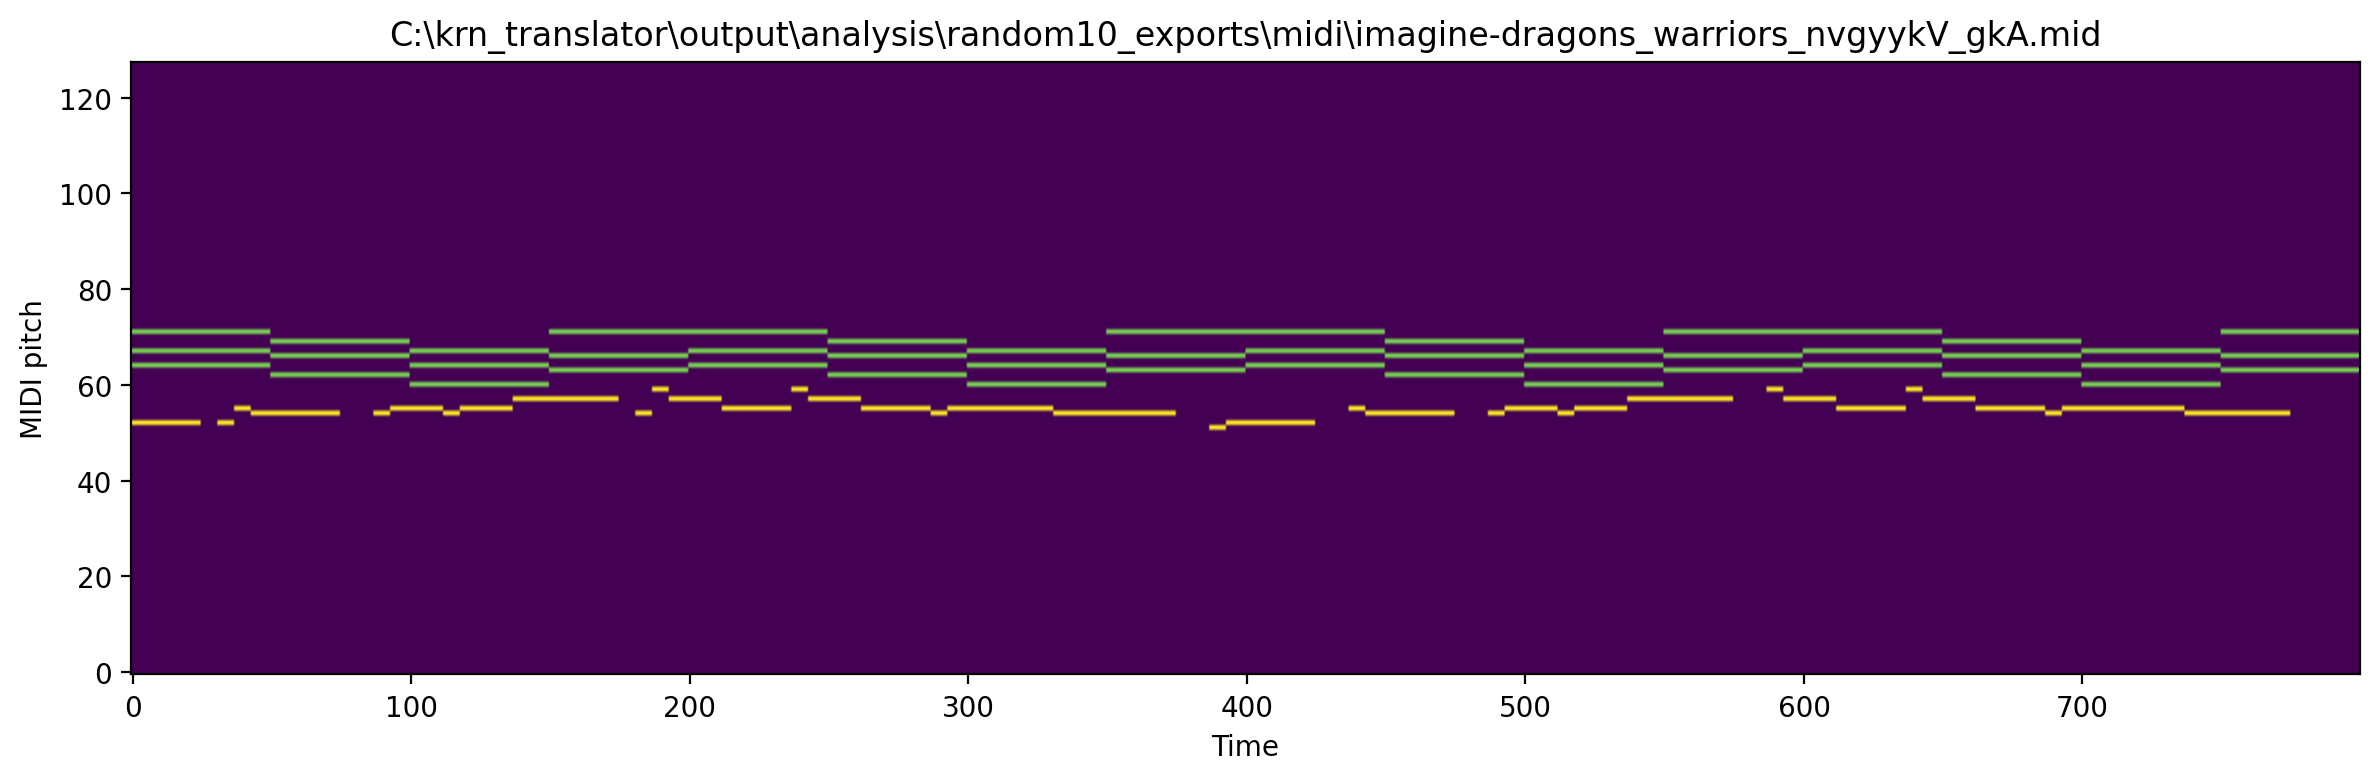

MuseScore path: C:\Program Files\MuseScore 4\bin\MuseScore4.exe


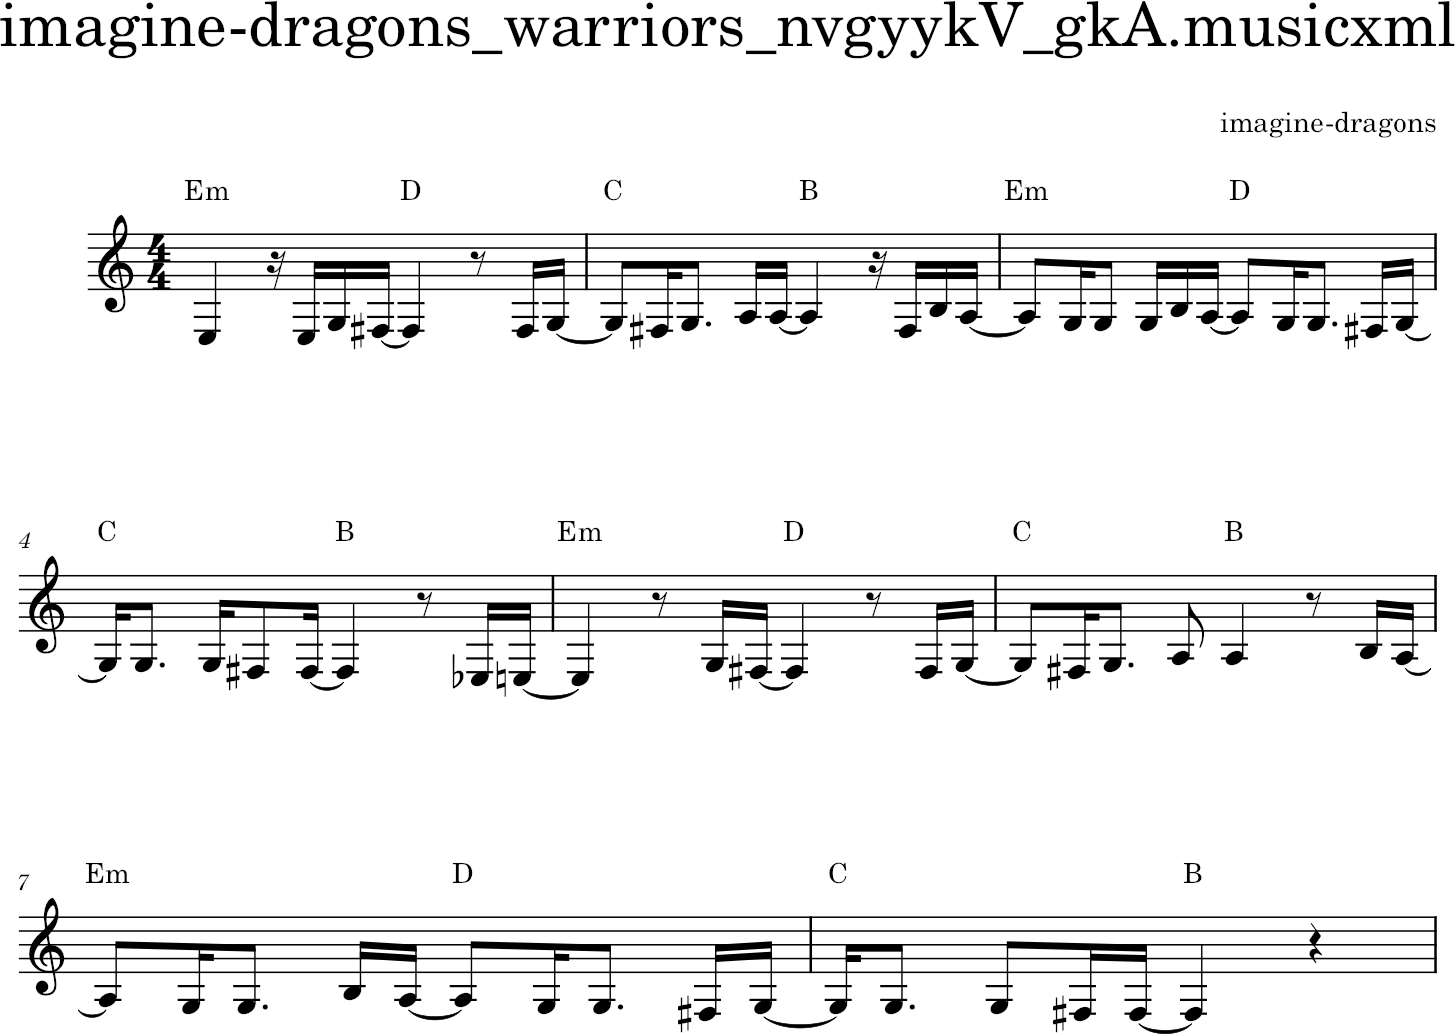

In [ ]:
import pretty_midi
import matplotlib.pyplot as plt
from IPython.display import Audio, display, Image
from music21 import converter, environment
from pathlib import Path

def configure_musescore():
    # 自动探测 Windows 常见安装路径
    candidates = [
        Path(r"C:\Program Files\MuseScore 4\bin\MuseScore4.exe"),
        Path(r"C:\Program Files\MuseScore 4\bin\MuseScore.exe"),
        Path(r"C:\Program Files\MuseScore 3\bin\MuseScore3.exe"),
        Path(r"C:\Program Files (x86)\MuseScore 3\bin\MuseScore3.exe"),
        Path.home() / r"AppData\Local\Programs\MuseScore 4\bin\MuseScore4.exe",
        Path.home() / r"AppData\Local\Programs\MuseScore 3\bin\MuseScore3.exe",
    ]
    exe = next((p for p in candidates if p.exists()), None)
    if exe is None:
        print("未找到 MuseScore 可执行文件。请确认你是‘安装完成’，不是只下载了安装器。")
        print("安装后可手动指定：")
        print("us = environment.UserSettings()")
        print("us['musescoreDirectPNGPath'] = r'C:\\...\\MuseScore4.exe'")
        return None

    us = environment.UserSettings()
    us['musescoreDirectPNGPath'] = str(exe)
    us['musicxmlPath'] = str(exe)
    print("MuseScore path:", exe)
    return exe

def preview_midi(midi_path, fs=16000):
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    audio = pm.synthesize(fs=fs)
    display(Audio(audio, rate=fs))

    pr = pm.get_piano_roll(fs=50)
    plt.figure(figsize=(12, 4))
    plt.imshow(pr, aspect='auto', origin='lower')
    plt.title(str(midi_path))
    plt.xlabel('Time')
    plt.ylabel('MIDI pitch')
    plt.tight_layout()
    plt.show()

def _render_score_to_png(score, tag='score'):
    png_path = score.write('musicxml.png')
    display(Image(filename=png_path))

def preview_musicxml_score(musicxml_path):
    _ = configure_musescore()
    score = converter.parse(str(musicxml_path))
    try:
        _render_score_to_png(score, tag='musicxml')
    except Exception as e:
        print('MusicXML 内联渲染失败：', e)
        print('将尝试外部打开 MusicXML。')
        score.show('musicxml')

def preview_krn_score(krn_path):
    _ = configure_musescore()
    krn_path = Path(krn_path)
    if not krn_path.exists():
        print('KRN 文件不存在：', krn_path)
        return
    try:
        score = converter.parse(str(krn_path))
        _render_score_to_png(score, tag='krn')
    except Exception as e:
        print('KRN 渲染失败：', e)
        print('可先把 KRN 转为 MusicXML 再预览，或检查该文件是否为标准 Humdrum **kern。')

preview_midi(sample_df.iloc[3]['midi_path'])
preview_musicxml_score(sample_df.iloc[3]['musicxml_path'])
preview_krn_score(sample_df.iloc[3]['krn_path'])

In [17]:
# 导出完整索引，便于后续审查
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
sample_df.to_csv(IDX_CSV, index=False, encoding='utf-8')
sample_df.to_json(IDX_JSON, orient='records', force_ascii=False, indent=2)

print('written:', IDX_CSV)
print('written:', IDX_JSON)
print('midi_dir:', MID_DIR)
print('musicxml_dir:', XML_DIR)


written: C:\krn_translator\output\analysis\random10_exports\sample10_index.csv
written: C:\krn_translator\output\analysis\random10_exports\sample10_index.json
midi_dir: C:\krn_translator\output\analysis\random10_exports\midi
musicxml_dir: C:\krn_translator\output\analysis\random10_exports\musicxml
